In [5]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [7]:
%pip install sentencepiece protobuf

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from transformers import (
    AutoModelForSequenceClassification,
    XLMRobertaTokenizerFast,
)

MODEL_PATH = Path(r"C:\Users\Dresler\Documents\La U\MachineLearn\entrenamientos\02_modelo_prototipo\modelo_entrenado")

                "id": "#VSC-27400203",
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"La carpeta del modelo no existe en: {MODEL_PATH}")

class_names = [
    "No Tóxico",
    "Lenguaje Ofensivo",
                "id": "#VSC-31df33c3",
    "Discurso de Odio",
    "Amenazas / Violencia",
]

print("Cargando tokenizer y modelo XLM-RoBERTa...")
# Usar explícitamente XLMRobertaTokenizerFast
                "id": "#VSC-d13c0c6e",
tokenizer = XLMRobertaTokenizerFast.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("¡Modelo cargado exitosamente!")

Cargando tokenizer y modelo XLM-RoBERTa...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

¡Modelo cargado exitosamente!


Ejecutando inferencias con XLM-RoBERTa...
¡Inferencia finalizada exitosamente!

F1-macro: 0.8058 (IC bootstrap 95%: 0.7665, 0.8420)

Métricas por clase (4 decimales):
                      precision  recall  f1-score
No Tóxico                0.8636  0.7724    0.8155
Lenguaje Ofensivo        0.7778  0.8365    0.8061
Discurso de Odio         0.7879  0.8211    0.8041
Amenazas / Violencia     0.8125  0.7831    0.7975


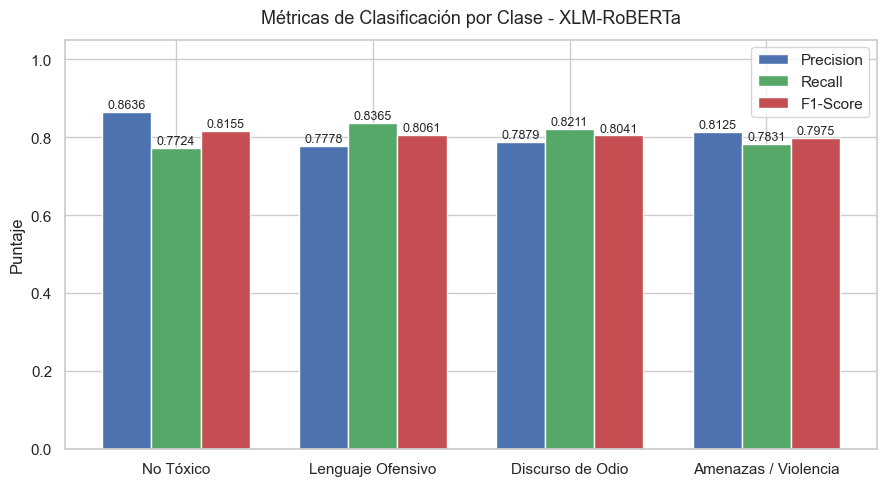


Matriz de confusión numérica:
                      No Tóxico  Lenguaje Ofensivo  Discurso de Odio  Amenazas / Violencia
No Tóxico                    95                 16                 7                     5
Lenguaje Ofensivo             9                133                 8                     9
Discurso de Odio              5                 11                78                     1
Amenazas / Violencia          1                 11                 6                    65


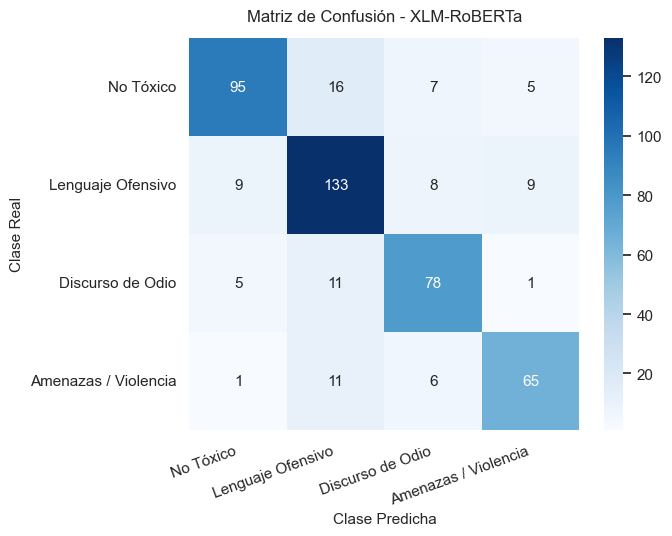

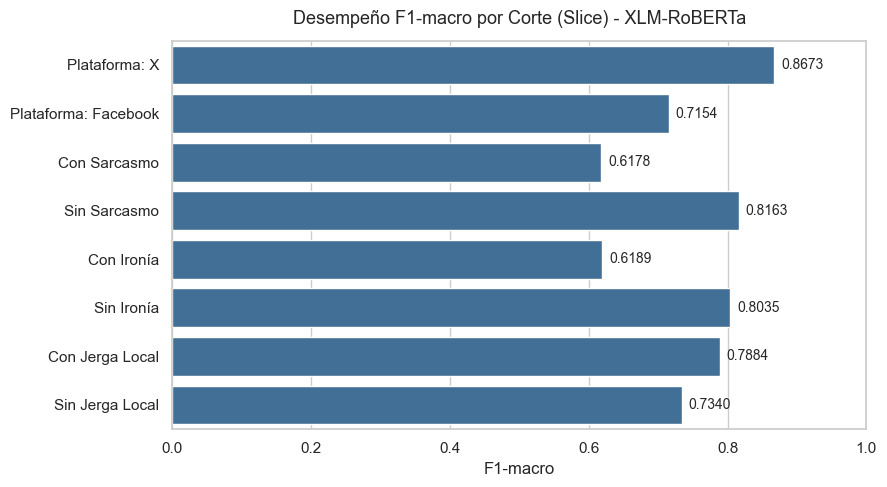


--- MÉTRICAS GLOBALES DE XLM-ROBERTA ---
                      precision    recall  f1-score   support

           No Tóxico     0.8636    0.7724    0.8155       123
   Lenguaje Ofensivo     0.7778    0.8365    0.8061       159
    Discurso de Odio     0.7879    0.8211    0.8041        95
Amenazas / Violencia     0.8125    0.7831    0.7975        83

            accuracy                         0.8065       460
           macro avg     0.8104    0.8033    0.8058       460
        weighted avg     0.8091    0.8065    0.8066       460



In [ ]:
                "id": "#VSC-bc0b3810",
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})
                "id": "#VSC-f0a834ac",

# 1. Configuración de nombres de columnas extraídos de tu dataset
CSV_TEST_PATH = r"C:\Users\Dresler\Documents\La U\MachineLearn\entrenamientos\01_dataset_y_entrenamiento\data\test.csv"

TEXT_COLUMN = "texto_modelo"
LABEL_COLUMN = "label"

                "id": "#VSC-a9cbe3e8",
class_names = [
    "No Tóxico",
    "Lenguaje Ofensivo",
    "Discurso de Odio",
    "Amenazas / Violencia",
]

# 2. Cargar datos
df_test = pd.read_csv(CSV_TEST_PATH)
y_true = df_test[LABEL_COLUMN].values


# 3. Función de inferencia rápida
def predict_texts(texts, batch_size=16):
    all_preds = []
    print("Ejecutando inferencias con XLM-RoBERTa...")
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt",
        )
        with torch.no_grad():
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)


def es_presencia(valor):
    return str(valor).strip().upper() in {"SI", "SÍ"}


def bootstrap_ci(y_real, y_estimado, metric=f1_score, n_bootstrap=2000, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y_real))
    scores = []
    for _ in range(n_bootstrap):
        muestra = rng.choice(indices, size=len(indices), replace=True)
        scores.append(metric(y_real[muestra], y_estimado[muestra], average="macro", zero_division=0))
    return np.percentile(scores, [2.5, 97.5])


# Ejecutar predicciones
y_pred = predict_texts(df_test[TEXT_COLUMN].astype(str).tolist())
df_test["y_pred"] = y_pred
print("¡Inferencia finalizada exitosamente!\n")

# Intervalo de confianza bootstrap del F1-macro
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_ci_low, f1_ci_high = bootstrap_ci(y_true, y_pred)
print(f"F1-macro: {f1_macro:.4f} (IC bootstrap 95%: {f1_ci_low:.4f}, {f1_ci_high:.4f})")

# --- GRÁFICO 1: Métricas por Clase ---
report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)

precisions = [report[c]["precision"] for c in class_names]
recalls = [report[c]["recall"] for c in class_names]
f1_scores = [report[c]["f1-score"] for c in class_names]

metrics_table = pd.DataFrame(
    {"precision": precisions, "recall": recalls, "f1-score": f1_scores},
    index=class_names,
)
print("\nMétricas por clase (4 decimales):")
print(metrics_table.to_string(float_format=lambda value: f"{value:.4f}"))

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, precisions, width, label="Precision", color="#4C72B0")
plt.bar(x, recalls, width, label="Recall", color="#55A868")
plt.bar(x + width, f1_scores, width, label="F1-Score", color="#C44E52")

plt.title("Métricas de Clasificación por Clase - XLM-RoBERTa", fontsize=13, pad=12)
plt.ylabel("Puntaje")
plt.xticks(x, class_names)
plt.ylim(0, 1.05)
plt.legend(loc="upper right")

for i in range(len(class_names)):
    plt.text(i - width, precisions[i] + 0.01, f"{precisions[i]:.4f}", ha="center", fontsize=9)
    plt.text(i, recalls[i] + 0.01, f"{recalls[i]:.4f}", ha="center", fontsize=9)
    plt.text(i + width, f1_scores[i] + 0.01, f"{f1_scores[i]:.4f}", ha="center", fontsize=9)

plt.savefig("xlmr_metricas_por_clase.png", dpi=300)
plt.show()


# --- GRÁFICO 2: Matriz de Confusión ---
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
cm_table = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nMatriz de confusión numérica:")
print(cm_table.to_string())

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True,
)
plt.title("Matriz de Confusión - XLM-RoBERTa", fontsize=12, pad=12)
plt.xlabel("Clase Predicha", fontsize=11)
plt.ylabel("Clase Real", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)

plt.savefig("xlmr_matriz_confusion.png", dpi=300)
plt.show()


# --- GRÁFICO 3: Métricas por Cortes (Slices) basada en las columnas de tu CSV ---
def get_f1_macro(df_sub):
    if len(df_sub) == 0:
        return 0.0
    return f1_score(df_sub[LABEL_COLUMN], df_sub["y_pred"], average="macro", zero_division=0)


slices_data = {}

# Slices por Plataforma
if "Plataforma" in df_test.columns:
    for plat in df_test["Plataforma"].dropna().unique():
        sub = df_test[df_test["Plataforma"] == plat]
        slices_data[f"Plataforma: {plat}"] = get_f1_macro(sub)

# Slices por Sarcasmo e Ironía
if "Presencia_Sarcasmo" in df_test.columns:
    presencia_sar = df_test["Presencia_Sarcasmo"].map(es_presencia)
    slices_data["Con Sarcasmo"] = get_f1_macro(df_test[presencia_sar])
    slices_data["Sin Sarcasmo"] = get_f1_macro(df_test[~presencia_sar])

if "Presencia_Ironia" in df_test.columns:
    presencia_iro = df_test["Presencia_Ironia"].map(es_presencia)
    slices_data["Con Ironía"] = get_f1_macro(df_test[presencia_iro])
    slices_data["Sin Ironía"] = get_f1_macro(df_test[~presencia_iro])

# Compatibilidad temporal con exportaciones antiguas del dataset
if "Presencia_Sar" in df_test.columns and "Presencia_Sarcasmo" not in df_test.columns:
    presencia_sar = df_test["Presencia_Sar"].map(es_presencia)
    slices_data["Con Sarcasmo"] = get_f1_macro(df_test[presencia_sar])
    slices_data["Sin Sarcasmo"] = get_f1_macro(df_test[~presencia_sar])

if "Presencia_Iro" in df_test.columns and "Presencia_Ironia" not in df_test.columns:
    presencia_iro = df_test["Presencia_Iro"].map(es_presencia)
    slices_data["Con Ironía"] = get_f1_macro(df_test[presencia_iro])
    slices_data["Sin Ironía"] = get_f1_macro(df_test[~presencia_iro])

# Slices por Jerga Local
if "n_jerga" in df_test.columns:
    sub_jerga = df_test[df_test["n_jerga"] > 0]
    sub_nojerga = df_test[df_test["n_jerga"] == 0]
    slices_data["Con Jerga Local"] = get_f1_macro(sub_jerga)
    slices_data["Sin Jerga Local"] = get_f1_macro(sub_nojerga)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=list(slices_data.values()), y=list(slices_data.keys()), color="#3470a3")
plt.title("Desempeño F1-macro por Corte (Slice) - XLM-RoBERTa", fontsize=13, pad=12)
plt.xlabel("F1-macro")
plt.xlim(0, 1.0)

for p in ax.patches:
    w = p.get_width()
    ax.annotate(
        f"{w:.4f}",
        (w + 0.01, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=10,
    )

plt.savefig("xlmr_metricas_slices.png", dpi=300)
plt.show()

# Resumen de métricas globales impresas
print("\n--- MÉTRICAS GLOBALES DE XLM-ROBERTA ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))


FPR de 'No Tóxico' por jerga (calculado desde y_true/y_pred):
                                 FPR
Sin Jerga Local (Estándar)    0.1596
Con Jerga Local (Salvadoreña) 0.4483


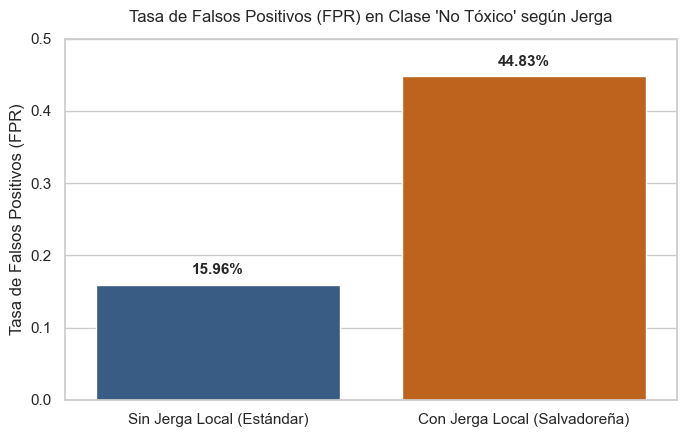

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

categorias_jerga = ["Sin Jerga Local (Estándar)", "Con Jerga Local (Salvadoreña)"]


def get_fpr_no_toxico(df_sub):
    """Calcula FPR binario: predicción tóxica en textos realmente no tóxicos."""
    no_toxico = df_sub[LABEL_COLUMN] == 0
    total_no_toxicos = no_toxico.sum()
    if total_no_toxicos == 0:
        return np.nan
    falsos_positivos = (df_sub.loc[no_toxico, "y_pred"] != 0).sum()
    return falsos_positivos / total_no_toxicos


if "n_jerga" not in df_test.columns:
    raise KeyError("El CSV no contiene la columna 'n_jerga' necesaria para calcular el FPR.")

sub_nojerga = df_test[df_test["n_jerga"] == 0]
sub_jerga = df_test[df_test["n_jerga"] > 0]
fpr_values = [get_fpr_no_toxico(sub_nojerga), get_fpr_no_toxico(sub_jerga)]
fpr_table = pd.DataFrame(
    {"FPR": fpr_values},
    index=categorias_jerga,
)
print("\nFPR de 'No Tóxico' por jerga (calculado desde y_true/y_pred):")
print(fpr_table.to_string(float_format=lambda value: f"{value:.4f}"))

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    x=categorias_jerga,
    y=fpr_values,
    hue=categorias_jerga,
    palette=["#2b5c8f", "#d95f02"],
    legend=False,
)

plt.title(
    "Tasa de Falsos Positivos (FPR) en Clase 'No Tóxico' según Jerga",
    fontsize=12,
    pad=12,
)
plt.ylabel("Tasa de Falsos Positivos (FPR)")
plt.ylim(0, 0.5)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h * 100:.2f}%",
        (p.get_x() + p.get_width() / 2.0, h + 0.01),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.savefig("xlmr_fpr_jerga.png", dpi=300)
plt.show()

In [ ]:
## Valores corregidos para §3.1

Los valores por plataforma que deben reportarse son **0.867** y **0.715**. Mantener tres decimales en esta sección.